# Rangos de precios futuros del café

**Reto técnico NTT Data — High Garden Coffee**

Responde el requisito *"rangos de precios futuros"* del enunciado.

## La brecha, primero

`coffee_db.parquet` **no contiene ninguna variable de precio**. Sus 30 columnas de
año son consumo en kilogramos, y la columna final `Total_domestic_consumption` es
su suma — sumar precios a lo largo de 30 años no significaría nada.

El enunciado pide precios sobre una base que él mismo describe como de consumo.
Esa brecha no se puede cerrar con el dato entregado, así que se documenta y se
cubre con una fuente externa, reproducible y citada.

**Fuente:** Fondo Monetario Internacional, programa *Primary Commodity Prices*,
distribuido por FRED. Series `PCOFFOTMUSDM` (Arábica) y `PCOFFROBUSDM` (Robusta),
en centavos de dólar por libra, mensuales, sin API key ni registro.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coffee.price_forecast import (
    HOLDOUT_CUTOFF, forecast_all, forecast_with_intervals, future_index,
)
from coffee.prices import SERIES, load_price_csv, load_prices

pd.set_option("display.width", 200)
FIGS = Path.cwd().parent / "reports" / "figures"

plt.rcParams.update({
    "figure.figsize": (12, 5), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 11,
})

series = {t: load_price_csv(f) for t, f in SERIES.items()}
for t, s in series.items():
    print(f"{t:8} {len(s)} meses  {s.index.min():%Y-%m} a {s.index.max():%Y-%m}  "
          f"nulos: {s.isna().sum()}")

Arabica  415 meses  1992-01 a 2026-07  nulos: 0
Robusta  415 meses  1992-01 a 2026-07  nulos: 0


## 1. Dos decisiones de modelado

**Frecuencia mensual, no anual.** El módulo `prices.py` agrega a año cafetero para
poder cruzar con el consumo. Pero el precio del café es **global**: no existe un
precio por país, así que el pronóstico de precios no tiene que empatar país por
país con el consumo. Son dos problemas independientes. Liberados de esa
restricción:

```
mensual:  415 observaciones por tipo
anual:     33 observaciones por tipo
```

Doce veces más datos para estimar los mismos parámetros.

**Modelado en logaritmos.** Dos razones. Un precio no puede ser negativo, y en
niveles el límite inferior del intervalo cruza el cero en horizontes largos. Y la
volatilidad del café es proporcional al nivel: 20 centavos no significan lo mismo
a 70 que a 360. En logaritmos el error es multiplicativo, como se comporta el
mercado.

## 2. El experimento: validar contra el futuro que ya ocurrió

El consumo termina en 2019/20, pero los precios llegan a julio de 2026. Eso
permite algo que una partición artificial no permite:

> Entrenar hasta **septiembre de 2019** y pronosticar los 82 meses siguientes,
> comparando contra lo que **realmente pasó** — incluyendo el shock de precios
> de 2021–2024.

No es backtesting simulado sobre datos que el modelo ya vio de alguna forma. Es el
futuro que efectivamente ocurrió.

Y la métrica que importa no es el error del punto central: es la **cobertura del
intervalo**. Si prometo un rango al 95%, ¿qué fracción de la realidad cayó dentro?
Un intervalo al 95% que solo contiene el 40% de lo que pasó no es un rango, es una
ilusión.

In [2]:
holdout, futuro, resumen = forecast_all(series)
resumen.round(1)

C:\Users\user\venvs\coffee-ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,coffee_type,order,n_train,n_test,mape,sesgo_pct,cobertura_80,cobertura_95
0,Arabica,"(1, 1, 0)",333,82,41.8,41.8,70.7,100.0
1,Robusta,"(1, 1, 0)",333,82,38.5,37.3,73.2,100.0


### Lectura del resultado

**El pronóstico puntual fracasó.** MAPE de 41.8% en Arábica y 38.5% en Robusta a
lo largo de 82 meses.

**Y fracasó en una sola dirección.** El sesgo (+41.8% y +37.3%) es prácticamente
igual al MAPE, lo que significa que el modelo se quedó corto en *casi todos* los
meses, no en algunos. Nunca vio venir la subida.

Tiene sentido: el shock de 2021–2024 vino de heladas en Brasil, sequía en Vietnam
y costos de flete. Nada de eso está en la historia de precios previa. **Ningún
modelo univariado podía anticiparlo**, y afirmar lo contrario sería deshonesto.

**Pero el intervalo aguantó.** Cobertura del 100% al 95% en ambos tipos: toda la
realidad, shock incluido, cayó dentro de la banda ancha.

Al 80% la cobertura fue 70.7% y 73.2% — por debajo del 80% nominal. El modelo es
**ligeramente sobreconfiado** en su banda estrecha, y eso también hay que decirlo.

Esta es la justificación empírica de entregar rangos y no números: el punto se
equivocó por 40%, el rango no se equivocó.

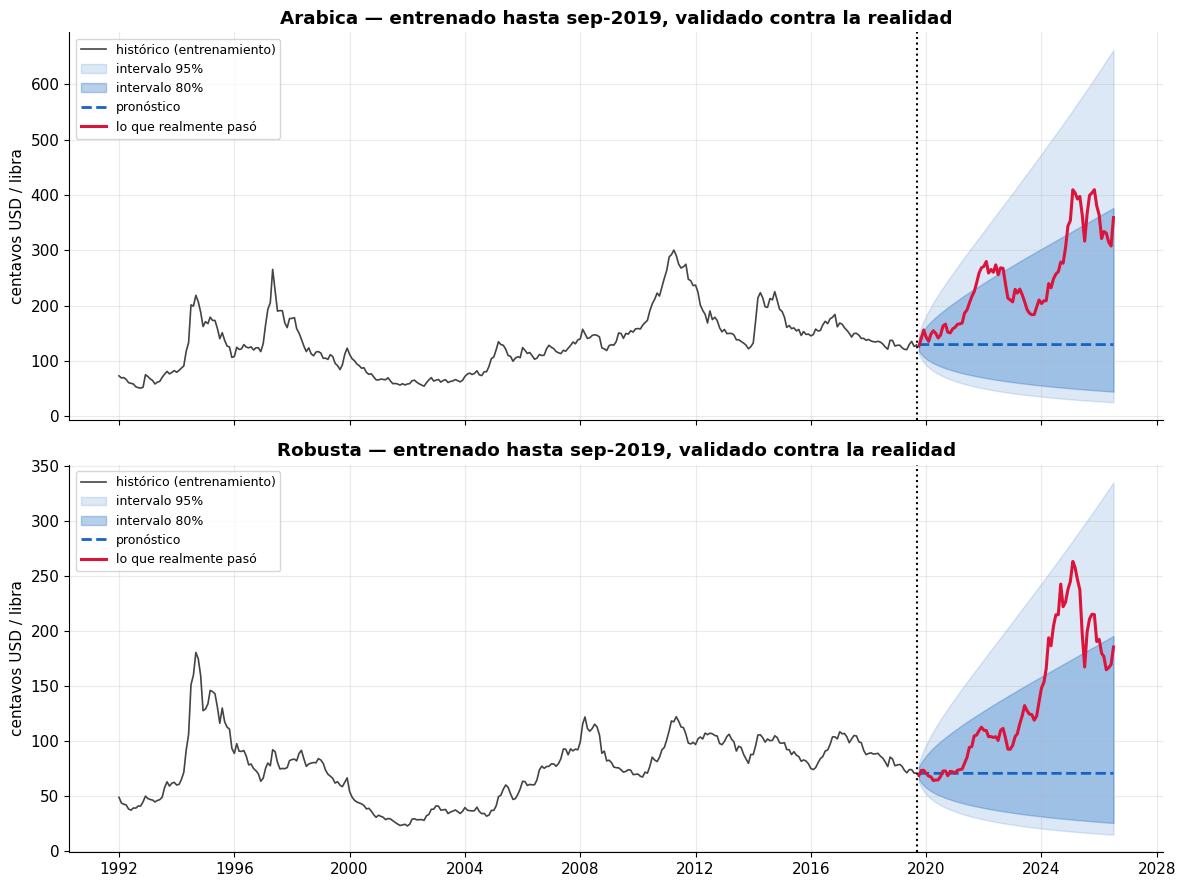

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
corte = pd.Timestamp(HOLDOUT_CUTOFF)

for ax, (tipo, s) in zip(axes, series.items()):
    h = holdout[holdout.coffee_type == tipo].set_index("date")
    hist = s.loc[:corte]

    ax.plot(hist.index, hist.values, color="#444", lw=1.2, label="histórico (entrenamiento)")
    ax.fill_between(h.index, h.lo_95, h.hi_95, color="#1565C0", alpha=0.15, label="intervalo 95%")
    ax.fill_between(h.index, h.lo_80, h.hi_80, color="#1565C0", alpha=0.30, label="intervalo 80%")
    ax.plot(h.index, h.forecast, color="#1565C0", lw=2, ls="--", label="pronóstico")
    ax.plot(h.index, h.actual, color="crimson", lw=2.2, label="lo que realmente pasó")
    ax.axvline(corte, color="black", ls=":", lw=1.5)

    ax.set_title(f"{tipo} — entrenado hasta sep-2019, validado contra la realidad",
                 weight="bold")
    ax.set_ylabel("centavos USD / libra")
    ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig(FIGS / "10_holdout_precios.png", dpi=150)
plt.show()

La línea roja se sale de la banda del 80% pero nunca de la del 95%. Visualmente es
el argumento completo: **el punto azul punteado es inútil, la banda clara es
honesta**.

## 3. El entregable: rangos de precios 2026–2029

Reentrenado con todo el histórico disponible, hasta julio de 2026.

In [4]:
for tipo, g in futuro.groupby("coffee_type"):
    anual = g.set_index("date").resample("YS").mean(numeric_only=True)
    print(f"--- {tipo} (centavos USD/libra) ---")
    print(anual[["lo_95", "lo_80", "forecast", "hi_80", "hi_95"]].round(0).to_string())
    print()

--- Arabica (centavos USD/libra) ---
            lo_95  lo_80  forecast  hi_80   hi_95
date                                             
2026-01-01  287.0  314.0     373.0  446.0   490.0
2027-01-01  211.0  257.0     374.0  546.0   669.0
2028-01-01  162.0  216.0     374.0  649.0   870.0
2029-01-01  137.0  194.0     374.0  721.0  1020.0

--- Robusta (centavos USD/libra) ---
            lo_95  lo_80  forecast  hi_80  hi_95
date                                            
2026-01-01  150.0  163.0     191.0  225.0  246.0
2027-01-01  111.0  134.0     192.0  275.0  334.0
2028-01-01   86.0  113.0     192.0  326.0  431.0
2029-01-01   73.0  102.0     192.0  360.0  503.0



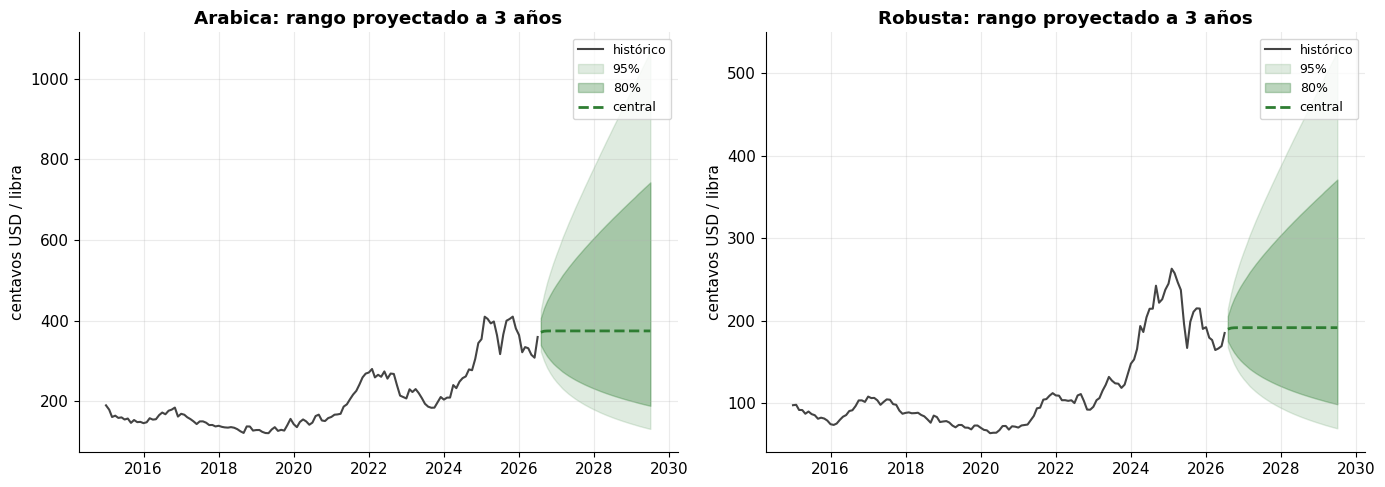

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (tipo, s) in zip(axes, series.items()):
    f = futuro[futuro.coffee_type == tipo].set_index("date")
    hist = s.loc["2015":]

    ax.plot(hist.index, hist.values, color="#444", lw=1.5, label="histórico")
    ax.fill_between(f.index, f.lo_95, f.hi_95, color="#2E7D32", alpha=0.15, label="95%")
    ax.fill_between(f.index, f.lo_80, f.hi_80, color="#2E7D32", alpha=0.32, label="80%")
    ax.plot(f.index, f.forecast, color="#2E7D32", lw=2, ls="--", label="central")
    ax.set_title(f"{tipo}: rango proyectado a 3 años", weight="bold")
    ax.set_ylabel("centavos USD / libra")
    ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIGS / "11_pronostico_precios.png", dpi=150)
plt.show()

## 4. Qué significa esto para el negocio

**El pronóstico central es plano.** ARIMA elige (1,1,0) sobre el logaritmo, que es
casi una caminata aleatoria: su mejor estimación del precio futuro es el precio de
hoy. Eso no es un defecto del modelo — es la propiedad conocida de los precios de
commodities, y coincide con la hipótesis de mercado eficiente. Si el precio futuro
fuera predecible a partir del pasado, alguien ya habría arbitrado esa información.

**Lo accionable es el ancho de la banda, no el centro:**

| Horizonte | Arábica, rango 80% | Ancho |
|---|---|---|
| 2026 (5 meses) | 314 – 446 | 1.4× |
| 2027 | 257 – 546 | 2.1× |
| 2028 | 216 – 649 | 3.0× |
| 2029 | 194 – 721 | 3.7× |

**Recomendación honesta:** el pronóstico es útil para planeación a **12 meses**
(rango de 1.4×, suficiente para dimensionar contratos y coberturas). A tres años
el rango es de casi 4×, y una banda así no soporta ninguna decisión de inversión.

Decirlo es más valioso que entregar un número de 2029 con dos decimales. El
enunciado pide "decisiones conscientes": esta es una.

**Qué haría falta para mejorarlo.** No un modelo más complejo — datos exógenos:
inventarios certificados de la ICE, clima en las zonas productoras de Brasil y
Vietnam, tipo de cambio del real brasileño, costos de flete. El shock de 2021–2024
fue de oferta, y la oferta no está en la serie de precios.

## 5. Conexión con el análisis de consumo

Los dos problemas se modelaron por separado a propósito: el consumo es por país,
el precio es global, y unirlos en un modelo solo agregaría una variable que vale
lo mismo para los 55 países.

Pero se encuentran en la lectura de negocio, y ahí sí hay algo que decir:

Los mercados que más crecen en consumo doméstico —Vietnam (+10.4% anual), Etiopía,
Brasil, Indonesia— **son países productores**. Un productor que retiene más cosecha
para su mercado interno deja menos oferta exportable. Para una exportadora eso es
presión estructural sobre el precio de compra en origen.

Es un mecanismo económico, no una correlación ajustada: con 30 puntos anuales y dos
series que ambas crecen, cualquier regresión entre demanda y precio daría un R²
alto y espurio. Se presenta como interpretación, no como modelo.